In [1]:
from src.utils import setup_client

hf_client = setup_client()

✅ Connected to TUDelft LLM proxy


### Loading dataset

In [2]:
import pandas as pd

dataset_name = 'college_biology'
splits = {
    'test': f'{dataset_name}/test-00000-of-00001.parquet',
    'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
    'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
}
base_url = "hf://datasets/cais/mmlu/"
df_full = pd.read_parquet(base_url + splits["test"])


In [3]:
df_full

,question,subject,choices,answer
0,Based on the characteristic population curves ...,college_biology,[maintain the population at a point correspond...,2
1,A frameshift mutation is created when,college_biology,"[telomeric sequences are removed from DNA, a c...",2
2,"To prevent desiccation and injury, the embryos...",college_biology,"[amnion, chorion, allantois, yolk sac]",0
3,Which of the following is a second messenger t...,college_biology,"[Prostaglandins, Inositol triphosphate, Cyclic...",1
4,Synthesis of an RNA/DNA hybrid from a single-s...,college_biology,[a DNA or RNA primer and reverse transcriptase...,0
...,...,...,...,...
139,Which of the following is a correct statement ...,college_biology,[The evaporation of water from leaf mesophyll ...,0
140,"In fungi, cell walls are reinforced by which o...",college_biology,"[Chitin, Silica, Lignin, Collagen fibers]",0
141,"In plants, proton pumps are involved in the pr...",college_biology,"[It is passive., It depends on DNA., It requir...",2
142,Which of the following characteristics is pred...,college_biology,[High niche divergence among co-occurring spec...,1


In [4]:
df_full.iloc[12]

question    In Sweden, the red fox (Vulpes vulpes) severel...
subject                                       college_biology
choices     [Both fox and hare populations will decrease.,...
answer                                                      2
Name: 12, dtype: object

In [5]:
# Choose one question and query the model
question_choice = 123 
question = df_full.iloc[question_choice]['question']
choices = df_full.iloc[question_choice]['choices']
answer = df_full.iloc[question_choice]['answer']
# convert 0-based index to letter
answer = chr(answer + ord('A'))

# generate the prompt
choices_text = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
remark = "Please only answer with a single letter (A, B, C, or D) and nothing else."
prompt = f"{question}\n" + "\n".join(choices_text) + "\n" + remark
print(f"Designed prompt for question {question_choice}:\n")
print("-" * 50)
print(prompt)
print("-" * 50)
print(f"Correct answer: {answer}")


Designed prompt for question 123:

--------------------------------------------------
An organism belonging to the nekton is which one of the following?
A. Whale
B. Barnacle
C. Cyanobacterium
D. Protist
Please only answer with a single letter (A, B, C, or D) and nothing else.
--------------------------------------------------
Correct answer: A


In [6]:
# import requests
# def query_model(prompt, model_name, max_tokens, client):
#     content = client.chat.completions.create(
#         model=model_name,
#         messages=[{"role": "user", "content": prompt}],
#         max_tokens=max_tokens,
#         logprobs=True
#     )
#     # Split the content into a dictionary for each token and its logprobs
#     answer = content.choices[0].message.content
#     logprobs_content = content.choices[0].logprobs.content
#     logprobs_dictionary = {x.token: x.logprob for x in logprobs_content}
#     token_prob_dictionary = {token: math.exp(logprobs_dictionary[token]) for token in logprobs_dictionary}
#     answer = {
#         "answer": answer,
#         "logprobs": logprobs_dictionary,
#         "token_probs": token_prob_dictionary
#     }
#     return answer

In [7]:
import requests
def query_model(prompt, model_name, max_tokens, client):
    """
    Parameters
    ----------
    prompt     : str   — the input text
    model_name : str   — "gpt2", "llama-1b", or "llama-8b"
    max_tokens : int   — how many tokens to generate (capped at 200 by proxy)
    client     : str   — the proxy URL returned by setup_client()

    Returns
    -------
    dict with keys:
        "answer"      : str   — the generated text
        "logprobs"    : dict  — {token: logprob}
        "token_probs" : dict  — {token: probability}
    """
    response = requests.post(
        f"{client}/generate",
        json={
            "prompt": prompt,
            "model": model_name,
            "max_tokens": max_tokens,
        },
        timeout=60,
    )

    if response.status_code == 429:
        print("⏳ Rate limit hit — wait a moment and try again.")
        return None

    if response.status_code == 400:
        print(f"❌ Bad request: {response.json().get('detail')}")
        return None

    response.raise_for_status()
    return response.json()


In [8]:
# from src.utils import setup_client
# client = setup_client()

# result = query_model(
#     prompt     = "The mitochondria is",
#     model_name = "meta-llama/Llama-3.2-1B-Instruct",       # start here — free, fast
#     max_tokens = 20,
#     client     = client,
# )

# result

In [9]:
model_name = "meta-llama/Llama-3.1-8B-Instruct" #"meta-llama/Llama-3.1-8B-Instruct" # "meta-llama/Llama-3.2-1B-Instruct" 

result = query_model(prompt, model_name, max_tokens=5, client=hf_client)

print(f"Model's answer: {result['answer']}")
print("Token probabilities for each token in the answer:")
print(result['token_probs'])
print(f"Correct answer: {df_full.iloc[question_choice]['answer']}")


Model's answer: A
Token probabilities for each token in the answer:
{'A': 0.9999264532796961, '<|eot_id|>': 0.8311362219006175}
Correct answer: 0


In [10]:
models = [
    "meta-llama/Llama-3.1-8B-Instruct",   # current - already working
    "meta-llama/Llama-3.2-1B-Instruct",   # tiny
]

for model in models:
    result = query_model(prompt, model, max_tokens=5, client=hf_client)
    print(f"Model: {model}")
    print(f"Model's answer: {result['answer']} | Correct answer: {answer}")
    print(f"Token probs for each token in the answer: {result['token_probs']}")
    print(f"--" * 20)

Model: meta-llama/Llama-3.1-8B-Instruct
Model's answer: A | Correct answer: A
Token probs for each token in the answer: {'A': 0.9999264532796961, '<|eot_id|>': 0.8311362219006175}
----------------------------------------
Model: meta-llama/Llama-3.2-1B-Instruct
Model's answer: D | Correct answer: A
Token probs for each token in the answer: {'D': 0.6372377522488211, '': 0.9999969005680498}
----------------------------------------


## Testing first 5 rows of dataset

In [11]:
# batch the dataframe so we send fewer requests to the model, and get more answers in one go
# batch_size = 10
# prompts = []
# for i in range(0, len(df_full), batch_size):
#     batch = df_full.iloc[i:i+batch_size]
#     batch_prompt = f"Answer the following {batch_size} multiple choice questions. \n"
#     batch_prompt += "For each question, please only answer with a question number followed by a letter (A, B, C, or D) and nothing else.\n"
#     for idx, row in batch.iterrows():
#         question = row['question']
#         choices = row['choices']
#         choices_text = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
#         #remark = "Please only answer with a single letter (A, B, C, or D) and nothing else."
#         prompt = f"{idx+1}: {question}\n" + "\n".join(choices_text) 
#         batch_prompt += prompt + "\n\n"
#     prompts.append(batch_prompt)

def batch_dataframe_into_prompts(df, batch_size, prefix=None, suffix=None):
    prompts = []
    correct_answers = []
    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i+batch_size]
        corrent_answers_this_batch = {}
        if prefix:
            batch_prompt = prefix + "\n"
        else:
            batch_prompt = f"Answer the following {batch_size} multiple choice questions. \n"
            batch_prompt += "For each question, please only answer with a question number followed by a letter (A, B, C, or D) and nothing else.\n"
        
        for idx, row in batch.iterrows():
            question = row['question']
            choices = row['choices']
            choices_text = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
            prompt = f"{idx+1}: {question}\n" + "\n".join(choices_text) 
            batch_prompt += prompt + "\n\n"
            corrent_answers_this_batch[idx+1] = chr(row['answer'] + ord('A'))
        if suffix:
            batch_prompt += suffix
            
        prompts.append(batch_prompt)
        correct_answers.append(corrent_answers_this_batch)
    return prompts, correct_answers



In [12]:
batch_size = 50
prompts, correct_answers = batch_dataframe_into_prompts(df_full, batch_size=batch_size)

In [16]:
batch_to_query = 0
sample_prompt = prompts[batch_to_query]
sample_correct_answers = correct_answers[batch_to_query]

print(f"Sample prompt for batch {batch_to_query}:\n")
print("-" * 50)
print(sample_prompt)

Sample prompt for batch 0:

--------------------------------------------------
Answer the following 50 multiple choice questions. 
For each question, please only answer with a question number followed by a letter (A, B, C, or D) and nothing else.
1: Based on the characteristic population curves that result from plotting population growth of a species, the most effective means of controlling the mosquito population is to
A. maintain the population at a point corresponding to the midpoint of its logistic curve
B. opt for zero population control once the K value of the curve has been reached
C. reduce the carrying capacity cif the environment to lower the K value
D. increase the mortality rate

2: A frameshift mutation is created when
A. telomeric sequences are removed from DNA
B. a codon's nucleotide sequence changes so that it calls for production of a different amino acid than the original one
C. a base pair is either inserted or deleted in a gene
D. a codon's nucleotide sequence is ch

In [19]:

result = query_model(sample_prompt, model_name, max_tokens=5000, client=hf_client)
print(f"Model's answer:\n{result['answer']}")

Model's answer:
1: A
2: C
3: A
4: B
5: D
6: A
7: B
8: D
9: D
10: C
11: D
12: D
13: C
14: D
15: A
16: C
17: C
18: C
19: C
20: A
21: D
22: C
23: B
24: D
25: D
26: D
27: B
28: C
29: A
30: C
31: A
32: B
33: D
34: D
35: A
36: A
37: B
38: A
39: C
40: B
41: B
42: C
43: C
44: A
45: D
46: D
47: A
48: C
49: B
50: A


{'1': -0.006146338768303394,
 ':': -0.00014065706636756659,
 ' A': -0.0005697772721759975,
 '\n': -0.00016497205069754273,
 '2': -7.009260298218578e-05,
 ' C': -0.06413493305444717,
 '3': -4.291525328881107e-06,
 '4': -5.602820692729438e-06,
 ' B': -0.21024852991104126,
 '5': -4.410734163684538e-06,
 ' D': -0.6781263947486877,
 '6': -1.4662635294371285e-05,
 '7': -2.861018856492592e-06,
 '8': -2.50339189733495e-06,
 '9': -5.006777428206988e-06,
 '10': -5.125986263010418e-06,
 '11': -8.4638240878121e-06,
 '12': -4.684815212385729e-05,
 '13': -1.7762025890988298e-05,
 '14': -1.8596476365928538e-05,
 '15': -2.145764938177308e-06,
 '16': -4.291525328881107e-06,
 '17': -1.4305104514278355e-06,
 '18': -4.529942543740617e-06,
 '19': -2.407998726994265e-05,
 '20': -4.768360213347478e-06,
 '21': -9.536697689327411e-06,
 '22': -1.0728830375228426e-06,
 '23': -1.6689286894688848e-06,
 '24': -2.7418097943154862e-06,
 '25': -2.169585604860913e-05,
 '26': -3.6954811548639555e-06,
 '27': -5.841237907

In [18]:
def parse_answers(model_answer):
    answers_dict = {}
    lines = model_answer.strip().split("\n")
    for line in lines:
        if ": " in line:
            question_num, answer = line.split(": ", 1)
            answers_dict[question_num.strip()] = answer.strip()
    return answers_dict

def parse_answers_with_token_prob(result):
    answers_dict = {}
    lines = result['answer'].strip().split("\n")
    for line in lines:
        if ": " in line:
            question_num, answer = line.split(": ", 1)
            answers_dict[question_num.strip()] = {
                "answer": answer.strip(),
                "token_probs": result['token_probs']
            }
    return answers_dict
answers_dict = parse_answers(result['answer'])
print("Parsed answers:")
print(answers_dict)
# evaluate the answers

def evaluate_batched_answers(correct_answers_batch, answers_dict, verbose=False):
    correct_count = 0
    for question_num, correct_answer in correct_answers_batch.items():
        model_answer = answers_dict.get(str(question_num), None)
        if model_answer == correct_answer:
            correct_count += 1
        if verbose:
            print(f"Question {question_num}: Correct answer = {correct_answer}, Model answer = {model_answer}, {'✅' if model_answer == correct_answer else '❌'}")
    return correct_count / len(correct_answers_batch)
accuracy = evaluate_batched_answers(sample_correct_answers, answers_dict, verbose=True)

print(f"Model accuracy on {batch_size} questions: {accuracy:.2%}")

Parsed answers:
{'1': 'C', '2': 'C', '3': 'A', '4': 'B', '5': 'D', '6': 'A', '7': 'B', '8': 'D', '9': 'D', '10': 'C', '11': 'A', '12': 'D', '13': 'C', '14': 'D', '15': 'C', '16': 'C', '17': 'C', '18': 'A', '19': 'C', '20': 'A', '21': 'D', '22': 'C', '23': 'B', '24': 'A', '25': 'D', '26': 'D', '27': 'A', '28': 'C', '29': 'A', '30': 'C', '31': 'D', '32': 'B', '33': 'D', '34': 'D', '35': 'A', '36': 'A', '37': 'C', '38': 'A', '39': 'C', '40': 'C', '41': 'A', '42': 'B', '43': 'D', '44': 'A', '45': 'D', '46': 'A', '47': 'B', '48': 'C', '49': 'B', '50': 'A'}
Question 1: Correct answer = C, Model answer = C, ✅
Question 2: Correct answer = C, Model answer = C, ✅
Question 3: Correct answer = A, Model answer = A, ✅
Question 4: Correct answer = B, Model answer = B, ✅
Question 5: Correct answer = A, Model answer = D, ❌
Question 6: Correct answer = A, Model answer = A, ✅
Question 7: Correct answer = B, Model answer = B, ✅
Question 8: Correct answer = B, Model answer = D, ❌
Question 9: Correct answer

In [32]:
# Compute model accuracy for the batch

print(f"Model accuracy on batch of {batch_size} questions: {accuracy:.2%}")

Model accuracy on batch of 10 questions: 0.00%


In [31]:
import math
# limit dataset to first 5 rows, just to test
df = df_full.head(10).copy() 
batch_size = 10
# maps the integer answers from the data set, to the actual letters used in the prompt
ANSWER_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}



model_name = "meta-llama/Llama-3.2-1B-Instruct" 
max_output_tokens = 5 # only 5 as we just want one single letter as output from the model

results = [] # to store results of api calls

print(f"\nStarting API calls for {len(df)} questions in batches of {batch_size}...\n")
batched_prompts, batched_answers = batch_dataframe_into_prompts(df, batch_size=batch_size) 


# iterate through batched prompts and make API calls for each batch, then evaluate the results
for batch_index, (batch_prompt, correct_answers_batch) in enumerate(zip(batched_prompts, batched_answers)):

    # make API call and store log probabilities!
    try:
        result = query_model(batch_prompt, model_name, max_tokens=500, client=hf_client)

        
        # Process the response of the model
        final_answer = result['answer']
        
        
            
        results.append({
            'id': batch_index,
            'question': batch_prompt,
            'correct_answer': correct_answers_batch,
            'model_answer': final_answer,
            'is_correct': final_answer == correct_answer_letter,
            'chosen_logprob': chosen_logprob,
            'chosen_probability': safe_probability
        })

        answer_is_incorrect = final_answer != correct_answer_letter
        # prints where we are in the iteration and highlight incorrect answers with an asterisk
        if answer_is_incorrect:
            print(f"* Q {index+1}: Correct={correct_answer_letter}, Model={final_answer}, LogProb={chosen_logprob:.10f}, Prob={safe_probability*100:.10f}%")
        else:
            print(f"Q {index+1}: Correct={correct_answer_letter}, Model={final_answer}, LogProb={chosen_logprob:.10f}, Prob={safe_probability*100:.10f}%")

    except Exception as e:
        print(f"Error during API call for Q {index+1}: {e}. Skipping...")
        continue
        
print("\nAPI calls complete.")

# quick analysation of results
results_df = pd.DataFrame(results)
print("\n--- Results Summary (First 5 Questions) ---")
print(f"Total questions processed: {len(results_df)}")
print(f"Overall Accuracy: {results_df['is_correct'].mean():.6f}")



Starting API calls for 10 questions
* Q 1: Correct=C, Model=A, LogProb=0.7274119134, Prob=72.7411913446%
* Q 2: Correct=C, Model=B, LogProb=0.2934177541, Prob=29.3417754054%
* Q 3: Correct=A, Model=D, LogProb=0.4527256505, Prob=45.2725650476%
* Q 4: Correct=B, Model=D, LogProb=0.7777723745, Prob=77.7772374505%
* Q 5: Correct=A, Model=D, LogProb=0.5197545385, Prob=51.9754538537%
* Q 6: Correct=A, Model=D, LogProb=0.6953231452, Prob=69.5323145179%
Q 7: Correct=B, Model=B, LogProb=0.9607424066, Prob=96.0742406638%
* Q 8: Correct=B, Model=D, LogProb=0.8933018314, Prob=89.3301831427%
* Q 9: Correct=D, Model=A, LogProb=0.0897559907, Prob=8.9755990682%
Q 10: Correct=C, Model=C, LogProb=0.8724442279, Prob=87.2444227864%

API calls complete.

--- Results Summary (First 5 Questions) ---
Total questions processed: 10
Overall Accuracy: 0.200000


## Testing out the creation of first calibration plot


Expected Calibration Error (ECE): 0.096438
--------------------------------------------------


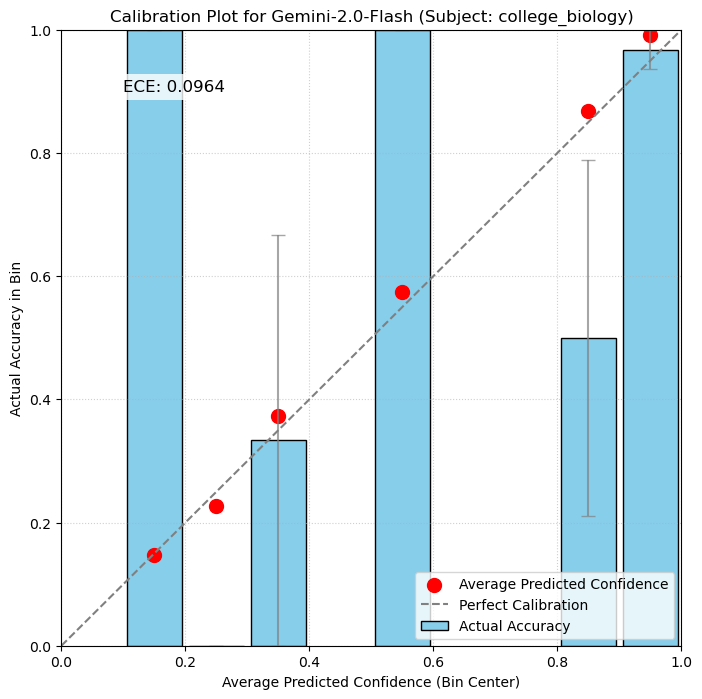

In [10]:
import matplotlib.pyplot as plt
import numpy as np
# Create calibration plot, using the Expected Calibration Error (ECE)
NUM_BINS = 10 
bin_edges = np.linspace(0.0, 1.0, NUM_BINS + 1) 

# ensure there is something in results_df
if len(results_df) == 0:
    print("error: results_df is empty.")
    exit()

# bin the confidence scores, using pd.cut (assigns data values to bins)
results_df['bin'] = pd.cut(
    results_df['chosen_probability'], 
    bins=bin_edges, 
    labels=False, 
    include_lowest=True # whether the first interval should be left-inclusive or not
)

# calculating metrics per bin
calibration_data = results_df.groupby('bin').agg(
    # calculate average predicted probability per bin
    avg_confidence=('chosen_probability', 'mean'),
    # calculate the actual accuracy, using the 'is_correct' boolean in the bin
    avg_accuracy=('is_correct', 'mean'),
    std_accuracy=('is_correct', 'std'), # standard deviation of accuracy in the bin, useful for error bars in the plot
    # count the samples in the bin
    count=('id', 'count') 
).reset_index() # reset_index moves the current index (the values of the 'bin' column) out of the index position and converts it back into a standard df column named 'bin'

# compute standard error of accuracy for error bars in the plot
calibration_data['accuracy_se'] = calibration_data['std_accuracy'] / np.sqrt(calibration_data['count'])
# replace nan values with 0s
calibration_data = calibration_data.fillna(0)

# calculate the center of each bin
def calculate_bin_center(bin_index):
    bin_index = int(bin_index) 
    return (bin_edges[bin_index] + bin_edges[bin_index + 1]) / 2.0

# get correct center for each row
calibration_data['bin_center'] = calibration_data['bin'].apply(calculate_bin_center)


# Calculate ECE!
# first the weights of each bin: (number of samples in bin) / (total number of samples)
calibration_data['weight'] = calibration_data['count'] / calibration_data['count'].sum()

# ECE
calibration_data['ece_term'] = calibration_data['weight'] * np.abs(
    calibration_data['avg_accuracy'] - calibration_data['avg_confidence']
)
ece = calibration_data['ece_term'].sum()

print(f"\nExpected Calibration Error (ECE): {ece:.6f}")
print("-" * 50)


# PLOT
fig, ax = plt.subplots(figsize=(8, 8))

# plot calibration curve (accuracy vs confidence)
ax.bar(
    calibration_data['bin_center'], 
    calibration_data['avg_accuracy'], 
    width=(1/NUM_BINS) * 0.9, # Bar width slightly less than bin width
    color='skyblue', 
    edgecolor='black',
    label='Actual Accuracy'
)

# plot difference between acc and conf
ax.scatter(
    calibration_data['bin_center'],
    calibration_data['avg_confidence'],
    marker='o',
    color='red',
    s=100,
    label='Average Predicted Confidence'
)

ax.errorbar(
    calibration_data['bin_center'],
    calibration_data['avg_accuracy'],
    yerr=calibration_data['accuracy_se'],
    fmt='none',
    ecolor='gray',
    alpha=0.7,
    capsize=5
)

# plot desired perfect calibration line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

# Set labels and title
ax.set_xlabel('Average Predicted Confidence (Bin Center)')
ax.set_ylabel('Actual Accuracy in Bin')
ax.set_title(f'Calibration Plot for Gemini-2.0-Flash (Subject: {dataset_name})')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

# Add ECE text to the plot
ax.text(0.1, 0.9, f'ECE: {ece:.4f}', transform=ax.transAxes, fontsize=12, 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Display the plot
plt.show()

Text(0, 0.5, 'Actual Accuracy in Bin')

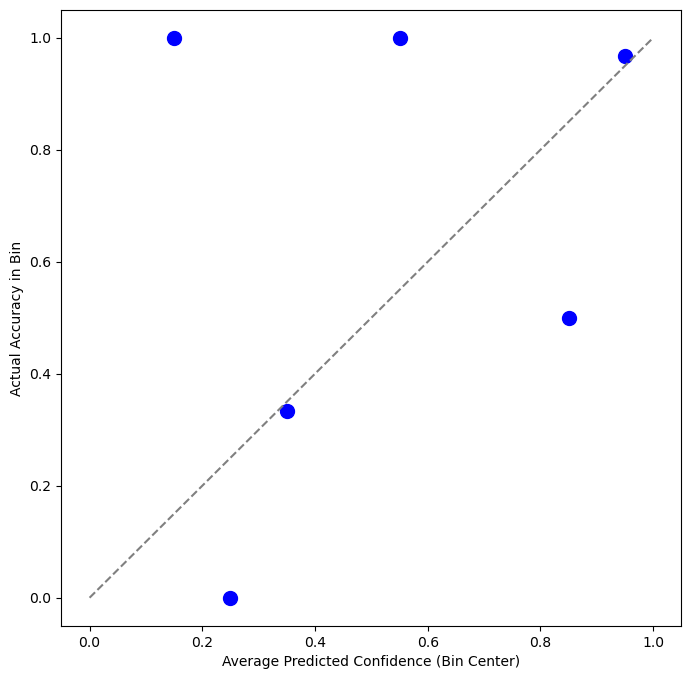

In [11]:
# Plot reliability curve with just scatter points and a dashed line for perfect calibration
fig, ax = plt.subplots(figsize=(8, 8))
# plot the reliability curve (accuracy vs confidence)
ax.scatter(
    calibration_data['bin_center'],
    calibration_data['avg_accuracy'],
    marker='o',
    color='blue',
    s=100,
    label='Actual Accuracy'
)
# plot the perfect calibration line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
# Set labels and title
ax.set_xlabel('Average Predicted Confidence (Bin Center)')
ax.set_ylabel('Actual Accuracy in Bin')


In [ ]:
results_df

## Defining calibration plot function


In [14]:


# Constants outside the function
ANSWER_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct" # "meta-llama/Llama-3.1-8B-Instruct" # "meta-llama/Llama-3.2-1B-Instruct"
MAX_OUTPUT_TOKENS = 5 
BASE_URL = "hf://datasets/cais/mmlu/"


def calibration_plot(dataset_name: str, number_of_bins: int):
    """
    Generates a calibration plot for the specified MMLU dataset using the Gemini API.

    Args:
        dataset_name (str): The name of the MMLU dataset subset (e.g., 'college_biology').
        number_of_bins (int): The number of bins to use for the calibration plot.
    """
    import os
    from src.utils import setup_client
    from tqdm import tqdm
    from time import sleep
    # DATA LOADING
    
    splits = {
        'test': f'{dataset_name}/test-00000-of-00001.parquet',
        'validation': f'{dataset_name}/validation-00000-of-00001.parquet',
        'dev': f'{dataset_name}/dev-00000-of-00001.parquet'
    }
    
    try:
        # Load the FULL dataset for proper calibration (removed .head(5))
        df = pd.read_parquet(BASE_URL + splits["test"])
    except Exception as e:
        print(f"Error loading dataset '{dataset_name}': {e}")
        return

    
    # API SET UP
    
    try:
        # Client needs to be accessible, assuming it's initialized globally or passed in.
        # Since your original code initializes it, we'll assume 'client' is defined here.
        client = setup_client()
        print("HF API Client initialized.")
    except Exception as e:
        print(f"Error when initializing client: {e}")
        return # Use return instead of exit() inside a function

    
    # API CALLS
    
    results = [] # to store results of api calls
    num_questions = len(df)
    print(f"\nStarting API calls for {num_questions} questions in '{dataset_name}'...")

    # iterate through dataframe
    for index, row in tqdm(df.iterrows(), total=num_questions, desc="Answering..."):
        # map the integer answer to the actual letter using the  ANSWER_MAP dict
        sleep(0.5)
        correct_answer_index = row['answer'] 
        correct_answer_letter = ANSWER_MAP.get(correct_answer_index, 'UNKNOWN')
        
        # skip if answer is unknown
        if correct_answer_letter == 'UNKNOWN':
            continue

        question_text = row['question'] # the actual question in the dataset
        choices = row['choices'] # the multiple choice options for the answer
        
        # make a nice format of the options so that the prompt is correct and easy to read
        option_lines = [f"{letter}. {text}" for letter, text in zip(['A', 'B', 'C', 'D'], choices)]
        
        # construct the final structured prompt
        full_prompt = (
            f"{question_text}\n" + 
            "\n".join(option_lines) +
            "\n\nPlease only answer with a single letter (A, B, C, or D) and nothing else."
        )
        
        # make API call and store log probabilities!
        try:
            result = query_model(full_prompt, MODEL_NAME, max_tokens=MAX_OUTPUT_TOKENS, client=client)
            # Process the response of the model
            final_answer = result['answer']
            logprob_content = result['logprobs']
            chosen_logprob = result['token_probs'][final_answer] if final_answer in result['token_probs'] else None
            safe_probability = min(chosen_logprob, 1.0) if chosen_logprob is not None else None
        
            results.append({
                'id': index,
                'correct_answer': correct_answer_letter,
                'model_answer': final_answer,
                'is_correct': final_answer == correct_answer_letter,
                'chosen_logprob': chosen_logprob,
                'chosen_probability': safe_probability
            })
            
            #if final_answer is None or chosen_logprob is None or safe_probability is None:
            #    print(f"Q {index+1}: WARNING: Model generated no tokens.")

        except Exception as e:
            # catch errors to prevent one single error of stopping entire function
            print(f"Error during API call for Q {index+1}: {e}. Skipping...")
            continue
            
    print("\nAPI calls complete.")

    
    # CALIBRATION
    
    results_df = pd.DataFrame(results)
    
    if len(results_df) == 0:
        print("error: results_df is empty after API calls.")
        return

    # quick analysation of results
    print("\n--- Results Summary ---")
    print(f"Total questions processed: {len(results_df)}")
    print(f"Overall Accuracy: {results_df['is_correct'].mean():.6f}")
    
    # Create calibration plot, using the Expected Calibration Error (ECE)
    bin_edges = np.linspace(0.0, 1.0, number_of_bins + 1) 

    # bin the confidence scores, using pd.cut
    results_df['bin'] = pd.cut(
        results_df['chosen_probability'], 
        bins=bin_edges, 
        labels=False, 
        include_lowest=True
    )

    # calculating metrics per bin
    calibration_data = results_df.groupby('bin').agg(
        avg_confidence=('chosen_probability', 'mean'),
        avg_accuracy=('is_correct', 'mean'),
        std_accuracy=('is_correct', 'std'), # standard deviation of accuracy in the bin, useful for error bars in the plot
        count=('id', 'count') 
    ).reset_index()

    # compute standard error of accuracy for error bars in the plot
    calibration_data['accuracy_se'] = calibration_data['std_accuracy'] / np.sqrt(calibration_data['count'])

    # replace nan values with 0s
    calibration_data = calibration_data.fillna(0)

    # calculate the center of each bin
    def calculate_bin_center(bin_index):
        bin_index = int(bin_index) 
        return (bin_edges[bin_index] + bin_edges[bin_index + 1]) / 2.0

    # get correct center for each row
    calibration_data['bin_center'] = calibration_data['bin'].apply(calculate_bin_center)


    # Calculate ECE!
    # first the weights of each bin
    calibration_data['weight'] = calibration_data['count'] / calibration_data['count'].sum()

    # ECE
    calibration_data['ece_term'] = calibration_data['weight'] * np.abs(
        calibration_data['avg_accuracy'] - calibration_data['avg_confidence']
    )
    ece = calibration_data['ece_term'].sum()

    print(f"\nExpected Calibration Error (ECE): {ece:.6f}")
    print("-" * 50)


    # PLOTTING
    
    fig, ax = plt.subplots(figsize=(8, 8))

    # plotting actual accuracy 
    ax.scatter(
        calibration_data['bin_center'],
        calibration_data['avg_accuracy'],
        marker='o',
        color='blue',
        s=100,
        label='Actual Accuracy'
    )

    ax.errorbar(
        calibration_data['bin_center'],
        calibration_data['avg_accuracy'],
        yerr=calibration_data['accuracy_se'],
        fmt='none',
        ecolor='gray',
        alpha=0.7,
        capsize=5
    )


    # Print number of samples in each bin
    for _, row in calibration_data.iterrows():
        count = row['count']
        center = row['bin_center']
        
        if count >= 0:
            # Set y-coordinate to a small fixed value (e.g., 0.02) just above the axis.
            # Use 'va="bottom"' to ensure the text starts at 0.02 and doesn't overlap the axis.
            ax.text(
                center, 
                0.02, # Fixed y-coordinate close to the bottom (X-axis)
                f'N={int(count)}',
                ha='center',       # Horizontal alignment (centered on the bar)
                va='bottom',       # Vertical alignment (text base starts at y=0.02)
                fontsize=9,        
                color='black',
                weight='bold'      # Added bolding for better visibility against the blue bar
            )
            

    # plot desired perfect calibration line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    # Set labels and title
    ax.set_xlabel('Average Predicted Confidence (Bin Center)')
    ax.set_ylabel('Actual Accuracy in Bin')
    ax.set_title(f'Calibration Plot for {MODEL_NAME} (Subject: {dataset_name}. Ntot={len(df)}.)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

    # Add ECE text to the plot
    ax.text(0.1, 0.9, f'ECE: {ece:.4f}', transform=ax.transAxes, fontsize=12, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # display the plot
    plt.show()




✅ Connected to TUDelft LLM proxy
HF API Client initialized.

Starting API calls for 144 questions in 'college_biology'...


Answering...: 100%|██████████| 144/144 [03:21<00:00,  1.40s/it]



API calls complete.

--- Results Summary ---
Total questions processed: 144
Overall Accuracy: 0.340278

Expected Calibration Error (ECE): 0.210297
--------------------------------------------------


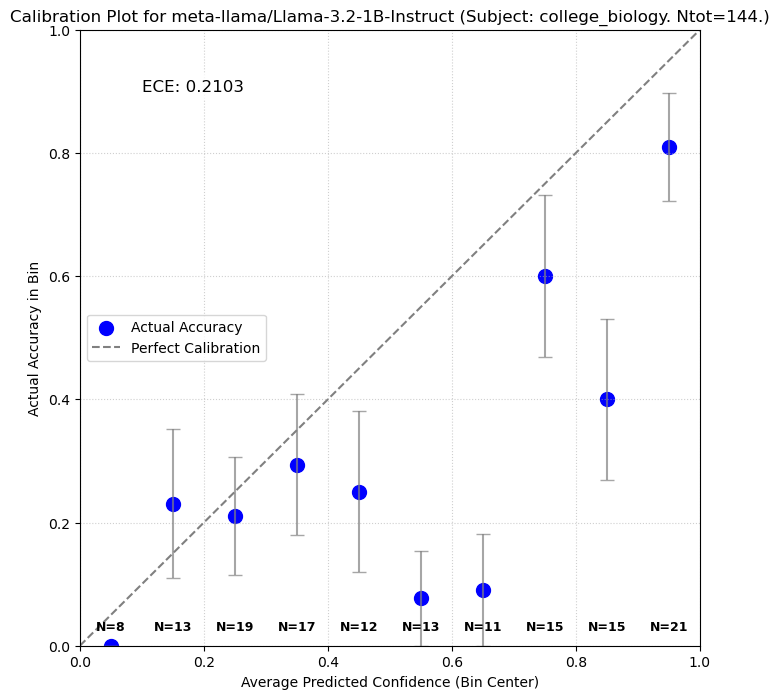

✅ Connected to TUDelft LLM proxy
HF API Client initialized.

Starting API calls for 173 questions in 'college_medicine'...


Answering...:  68%|██████▊   | 118/173 [02:44<01:16,  1.39s/it]


KeyboardInterrupt: 

In [15]:
number_of_bins = 10
data_sets = ['college_biology', 'college_medicine', 'conceptual_physics', 'econometrics', 'high_school_biology', 'high_school_psychology',
             'professional_medicine', 'professional_psychology']
#data_sets = ["professional_medicine", "professional_psychology"]
for data_set in data_sets:
    calibration_plot(data_set, number_of_bins)
